# Análisis Exploratorio de Datos (EDA)
## Estrés académico, sintomatología y biomarcadores

**Base:** `DATA.xlsx` — hoja `FULL DATA`  
**Documentación:** `CODEBOOK.pdf` y `Readme.txt`

### Objetivo

Realizar un análisis exploratorio reproducible de los principales indicadores del estudio, poniendo énfasis en:

- estrés académico SISCO-II;
- reacciones físicas y psicológicas;
- sintomatología depresiva (BDI-II);
- BDNF plasmático;
- metilación global del ADN (G-DNA-M);
- diferencias descriptivas según sexo;
- asociaciones monotónicas entre variables;
- estructura multivariada mediante PCA.




## Variables principales y criterio de selección

La base contiene 215 columnas porque incluye ítems individuales de distintos instrumentos y sus puntajes/resúmenes.

Para el EDA se priorizan variables resumen documentadas en el CODEBOOK:

- `BS.EASIS`, `FS.EASIS`: medida total de estrés académico SISCO-II, basal y final.
- `BS.RfsSIS`, `FS.RfsSIS`: reacciones físicas y psicológicas SISCO-II, basal y final.
- `BB.PT`, `FB.PT`: puntaje total BDI-II, basal y final.
- `BLAB.BDNF`, `FLAB.BDNF`: concentración de BDNF en ng/ml, basal y final.
- `BLAB.Met`, `FLAB.Met`: porcentaje de metilación, basal y final.
- Variables adicionales para PCA: estresores, reacciones sociales, afrontamiento, SRQ y AUDIT.

El CODEBOOK indica que `-9` representa valores perdidos y que `Sexo` está codificado como `0 = F` y `1 = M`.

**Nota sobre el CODEBOOK:** en la descripción del BDI-II final aparece `FB.97` para el ítem 7, mientras que la base `DATA.xlsx` contiene `FB.7`. Para reproducibilidad se utiliza el nombre que efectivamente existe en la base.


In [1]:
# ============================================================
# 1. Carga de librerías y configuración inicial
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# Carga de datos
excel_path = r'C:\Users\jenny\Documents\Data Science\base datos\DATA.xlsx'
df_raw = pd.read_excel(excel_path, sheet_name='FULL DATA')
df = df_raw.copy()


## Paso 2. Limpieza y preparación

Se realizan únicamente transformaciones documentadas o derivadas directamente de las variables disponibles:

1. `-9` se transforma en `NaN`, porque el CODEBOOK lo define como valor perdido.
2. Se crean etiquetas para sexo.
3. Se conservan los puntajes originales del BDI-II y, por separado, se calculan puntajes prorrateados.
4. Se calculan cambios longitudinales de BDNF y metilación.
5. Se identifican posibles valores atípicos mediante la regla de Tukey (`1.5 × IQR`).

### Correcciones de fechas

La versión anterior del notebook había identificado correcciones para los participantes ID 23 e ID 83. Como esas correcciones no están justificadas explícitamente en el CODEBOOK, se mantienen como una opción separada y documentada. **Antes de la entrega debe verificarse su origen en el registro original.**


In [2]:
# ============================================================
# 2. Limpieza y variables derivadas
# ============================================================
df = df_raw.copy()

# 2.1 Valores perdidos
df = df.replace(-9, np.nan)

# 2.2 Etiqueta de sexo según CODEBOOK
df["Sexo_Label"] = df[".Sexo"].map({0: "Mujer (F)", 1: "Hombre (M)"})

# 2.3 BDI-II: conservar puntajes originales y crear versión prorrateada
# Regla usada en la versión anterior: >=80% de ítems respondidos (>=17/21).
# Esta regla debe respaldarse con la referencia psicométrica correspondiente.
def prorratear_bdi(df_in, prefix):
    items = [f"{prefix}.{i}" for i in range(1, 22)]
    # La base DATA contiene FB.7; el CODEBOOK PDF presenta FB.97.
    disponibles = [c for c in items if c in df_in.columns]

    if len(disponibles) != 21:
        raise ValueError(f"No se encontraron los 21 ítems esperados para {prefix}.")

    n_validos = df_in[disponibles].notna().sum(axis=1)
    suma = df_in[disponibles].sum(axis=1, skipna=True)

    resultado = np.where(
        n_validos >= 17,
        np.round((suma / n_validos) * 21),
        np.nan
    )
    return pd.Series(resultado, index=df_in.index)

df["BB.PT_prorrateado"] = prorratear_bdi(df, "BB")
df["FB.PT_prorrateado"] = prorratear_bdi(df, "FB")

# 2.4 Cambios longitudinales
df["Delta_BDNF"] = df["FLAB.BDNF"] - df["BLAB.BDNF"]
df["Ratio_BDNF"] = df["FLAB.BDNF"] / df["BLAB.BDNF"]
df["log_ratio_BDNF"] = np.log(df["Ratio_BDNF"])
df["pct_change_BDNF"] = 100 * (df["FLAB.BDNF"] / df["BLAB.BDNF"] - 1)

df["Delta_Met"] = df["FLAB.Met"] - df["BLAB.Met"]
df["Delta_SISCO"] = df["FS.EASIS"] - df["BS.EASIS"]

# 2.5 Resumen de comprobación del BDI
display(
    df.loc[df[".ID"].isin([1, 59]),
           [".ID", "BB.PT", "BB.PT_prorrateado", "FB.PT", "FB.PT_prorrateado"]]
)

print("\nValores faltantes después de reemplazar -9:")
print(f"{df.isna().sum().sum()} celdas faltantes en total.")


,.ID,BB.PT,BB.PT_prorrateado,FB.PT,FB.PT_prorrateado
0,1,11.0,11.0,-4.0,5.0
48,59,12.0,12.0,NaN,14.0



Valores faltantes después de reemplazar -9:
96 celdas faltantes en total.


### Nota sobre el prorrateo del BDI-II

El prorrateo se mantiene como **variable derivada**, no se sobrescriben `BB.PT` ni `FB.PT`. Esto permite conservar la información original y distinguir claramente entre:

- puntaje total registrado en la base;
- puntaje prorrateado utilizado en el EDA.

La regla de prorrateo debe acompañarse de una referencia metodológica en el informe si se mantiene en la versión final.


## Paso 3. Calidad de datos y posibles valores atípicos

La identificación de valores atípicos mediante `1.5 × IQR` se utiliza exclusivamente como herramienta exploratoria.

**Un valor marcado como atípico no se elimina automáticamente.** Puede corresponder a una observación válida y, especialmente en variables biomoleculares, debe conservarse salvo que exista evidencia de error de medición o digitación.


In [3]:
# ============================================================
# 3. Resumen de valores faltantes y atípicos
# ============================================================

variables_eda = [
    "BS.EASIS", "FS.EASIS",
    "BS.RfsSIS", "FS.RfsSIS",
    "BB.PT_prorrateado", "FB.PT_prorrateado",
    "BLAB.BDNF", "FLAB.BDNF",
    "BLAB.Met", "FLAB.Met"
]

faltantes = pd.DataFrame({
    "Variable": variables_eda,
    "N": [df[c].notna().sum() for c in variables_eda],
    "N faltantes": [df[c].isna().sum() for c in variables_eda],
    "% faltantes": [100 * df[c].isna().mean() for c in variables_eda]
}).round(2)

display(faltantes)

def tukey_outliers(s):
    s = s.dropna()
    q1 = s.quantile(.25)
    q3 = s.quantile(.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    mask = (s < li) | (s > ls)
    return q1, q3, iqr, li, ls, int(mask.sum())

out_rows = []
for c in variables_eda:
    q1, q3, iqr, li, ls, nout = tukey_outliers(df[c])
    n = df[c].notna().sum()
    out_rows.append({
        "Variable": c,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Límite inferior": li,
        "Límite superior": ls,
        "N atípicos": nout,
        "% atípicos": 100*nout/n if n else np.nan
    })

outliers_df = pd.DataFrame(out_rows).round(2)
display(outliers_df)


,Variable,N,N faltantes,% faltantes
0,BS.EASIS,65,0,0.00
1,FS.EASIS,65,0,0.00
2,BS.RfsSIS,65,0,0.00
3,FS.RfsSIS,65,0,0.00
4,BB.PT_prorrateado,64,1,1.54
5,FB.PT_prorrateado,64,1,1.54
6,BLAB.BDNF,65,0,0.00
7,FLAB.BDNF,65,0,0.00
8,BLAB.Met,65,0,0.00
9,FLAB.Met,65,0,0.00


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,N atípicos,% atípicos
0,BS.EASIS,37.00,59.00,22.00,4.00,92.00,0,0.00
1,FS.EASIS,66.00,87.00,21.00,34.50,118.50,0,0.00
2,BS.RfsSIS,19.00,28.00,9.00,5.50,41.50,1,1.54
3,FS.RfsSIS,27.00,38.00,11.00,10.50,54.50,0,0.00
4,BB.PT_prorrateado,4.00,14.25,10.25,-11.38,29.62,1,1.56
5,FB.PT_prorrateado,9.00,25.00,16.00,-15.00,49.00,1,1.56
6,BLAB.BDNF,539.60,2149.00,1609.40,-1874.50,4563.10,8,12.31
7,FLAB.BDNF,463.50,2319.00,1855.50,-2319.75,5102.25,5,7.69
8,BLAB.Met,1.43,3.00,1.57,-0.92,5.35,3,4.62
9,FLAB.Met,1.49,3.12,1.63,-0.96,5.57,5,7.69


## Paso 4. Estadística descriptiva univariada

Para cada variable se reportan:

- `N`;
- media;
- desviación estándar;
- mediana;
- Q1 y Q3;
- IQR;
- asimetría.

Debido a la presencia de asimetría y valores extremos en algunas variables, la mediana y el IQR se utilizan como medidas robustas de referencia. Esto **no implica descartar la media**, que también se reporta para mantener una descripción completa.


In [4]:
# ============================================================
# 4. Tabla descriptiva
# ============================================================

variables_describir = [
    ("Estrés académico SISCO-II basal", "BS.EASIS"),
    ("Estrés académico SISCO-II final", "FS.EASIS"),
    ("Reacciones físicas/psicológicas basal", "BS.RfsSIS"),
    ("Reacciones físicas/psicológicas final", "FS.RfsSIS"),
    ("BDI-II basal (prorrateado)", "BB.PT_prorrateado"),
    ("BDI-II final (prorrateado)", "FB.PT_prorrateado"),
    ("BDNF basal (ng/ml)", "BLAB.BDNF"),
    ("BDNF final (ng/ml)", "FLAB.BDNF"),
    ("Metilación global basal (%)", "BLAB.Met"),
    ("Metilación global final (%)", "FLAB.Met")
]

rows = []
for label, col in variables_describir:
    s = df[col].dropna()
    q1 = s.quantile(.25)
    q3 = s.quantile(.75)
    rows.append({
        "Variable": label,
        "N": len(s),
        "Media": s.mean(),
        "Desv. Est.": s.std(),
        "Mediana": s.median(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "Asimetría": s.skew()
    })

df_resumen = pd.DataFrame(rows).round(2)
display(df_resumen)


,Variable,N,Media,Desv. Est.,Mediana,Q1,Q3,IQR,Asimetría
0,Estrés académico SISCO-II basal,65,50.17,14.54,49.00,37.00,59.00,22.00,0.55
1,Estrés académico SISCO-II final,65,76.22,16.29,81.00,66.00,87.00,21.00,-0.43
2,Reacciones físicas/psicológicas basal,65,23.91,6.63,24.00,19.00,28.00,9.00,0.35
3,Reacciones físicas/psicológicas final,65,32.68,8.42,34.00,27.00,38.00,11.00,-0.34
4,BDI-II basal (prorrateado),64,9.75,7.89,8.00,4.00,14.25,10.25,1.29
5,BDI-II final (prorrateado),64,17.75,10.93,16.50,9.00,25.00,16.00,0.86
6,BDNF basal (ng/ml),65,1800.43,1957.91,951.50,539.60,2149.00,1609.40,1.91
7,BDNF final (ng/ml),65,1676.94,1805.09,960.30,463.50,2319.00,1855.50,1.70
8,Metilación global basal (%),65,2.40,1.40,2.22,1.43,3.00,1.57,0.71
9,Metilación global final (%),65,2.57,1.91,2.06,1.49,3.12,1.63,2.68


### Observaciones descriptivas

Los textos interpretativos se generan a partir de la tabla anterior. No se fijan números manualmente en el Markdown, de modo que al cambiar la base o una decisión de limpieza, las conclusiones numéricas no quedan desactualizadas.


In [5]:
# Resumen automático de los cambios longitudinales principales
def resumen_cambio(col_base, col_final, nombre):
    base = df[col_base].dropna()
    final = df[col_final].dropna()
    print(
        f"{nombre}: mediana basal = {base.median():.2f}; "
        f"mediana final = {final.median():.2f}."
    )

resumen_cambio("BS.EASIS", "FS.EASIS", "Estrés académico SISCO-II")
resumen_cambio("BS.RfsSIS", "FS.RfsSIS", "Reacciones físicas/psicológicas")
resumen_cambio("BLAB.BDNF", "FLAB.BDNF", "BDNF")
resumen_cambio("BLAB.Met", "FLAB.Met", "Metilación global")


Estrés académico SISCO-II: mediana basal = 49.00; mediana final = 81.00.
Reacciones físicas/psicológicas: mediana basal = 24.00; mediana final = 34.00.
BDNF: mediana basal = 951.50; mediana final = 960.30.
Metilación global: mediana basal = 2.22; mediana final = 2.06.


## Paso 5. Distribuciones

Se utilizan histogramas para comparar las mediciones basal y final. La KDE se incorpora únicamente como apoyo visual.

No se interpreta una KDE como evidencia de normalidad ni se utilizan las formas de las curvas para establecer puntos de corte biológicos.


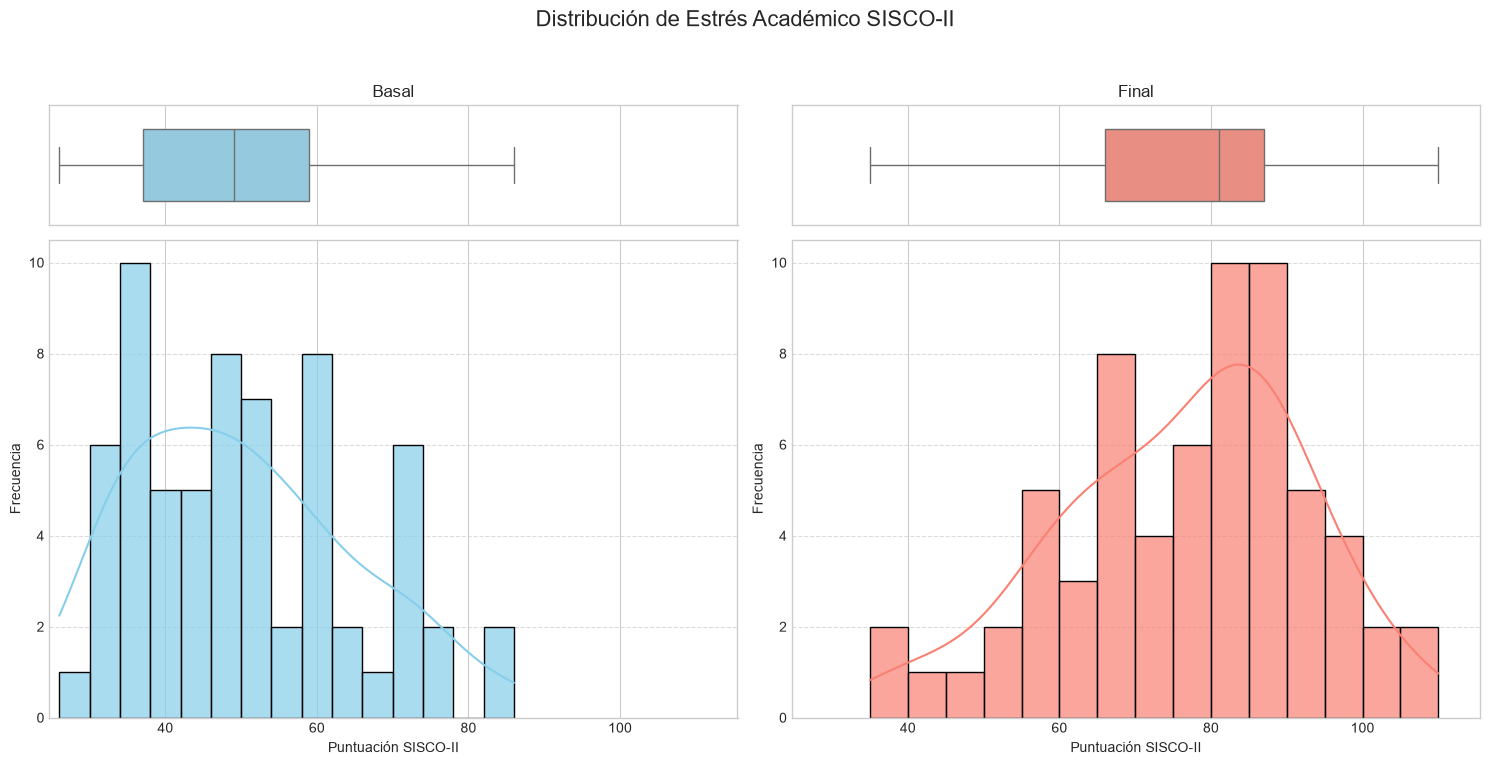

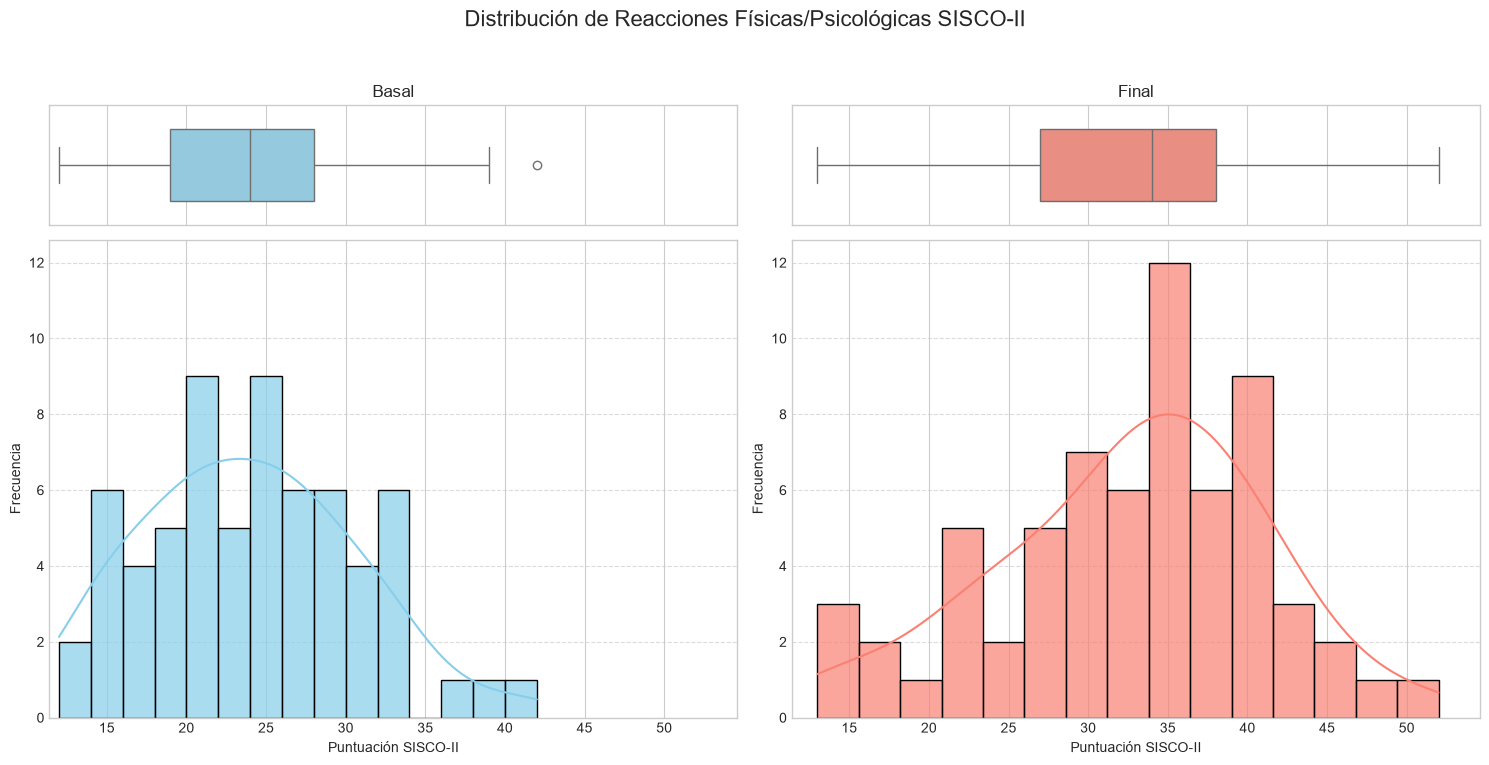

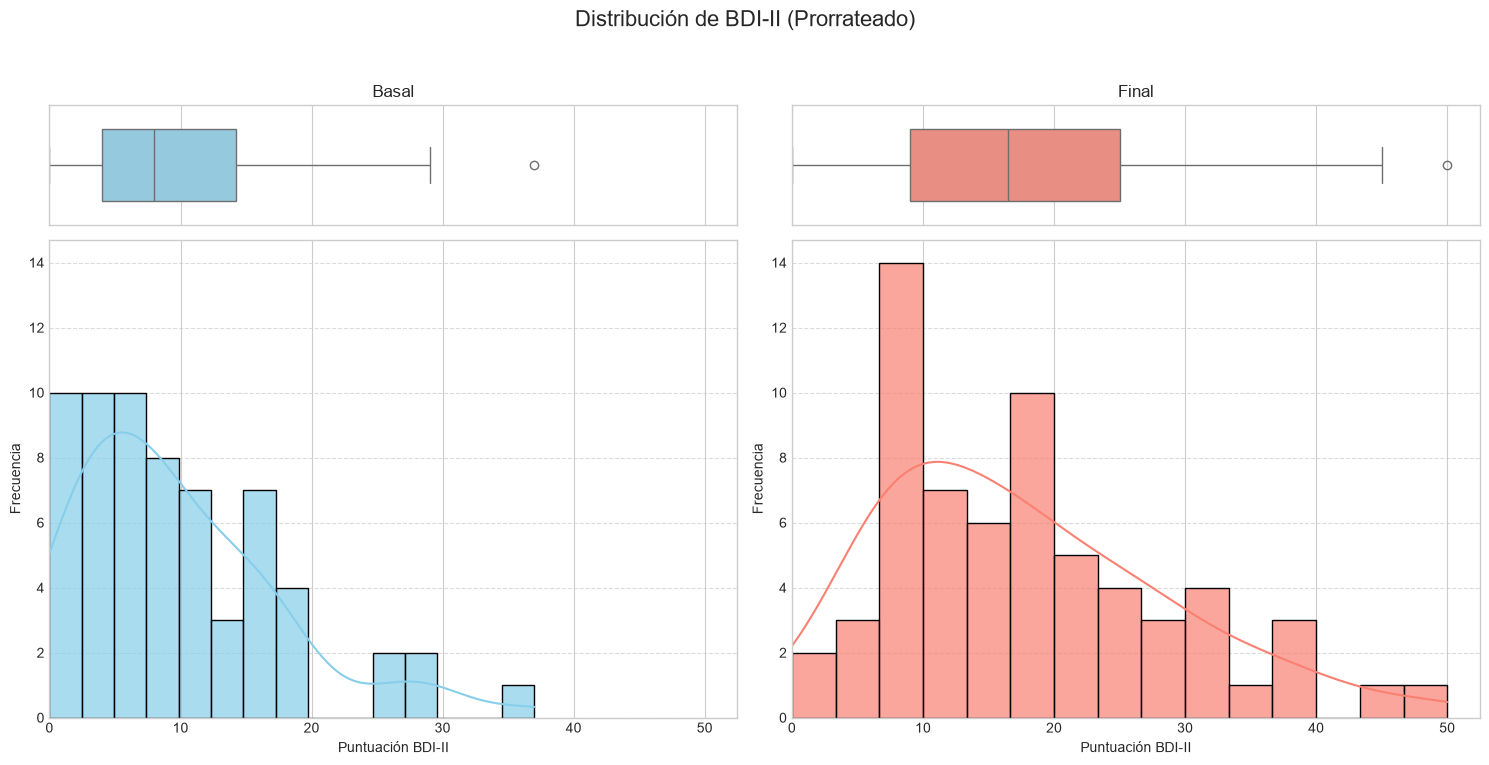

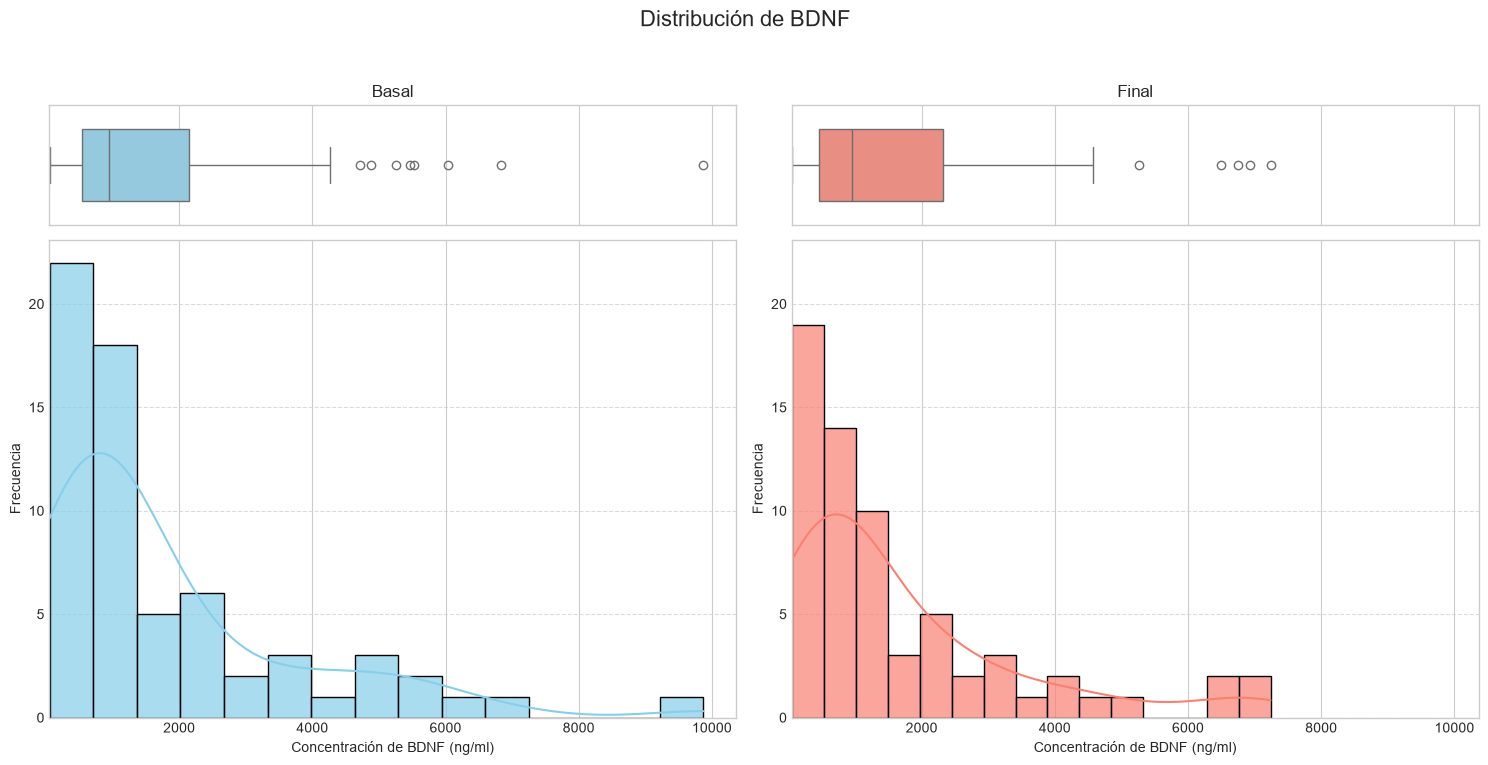

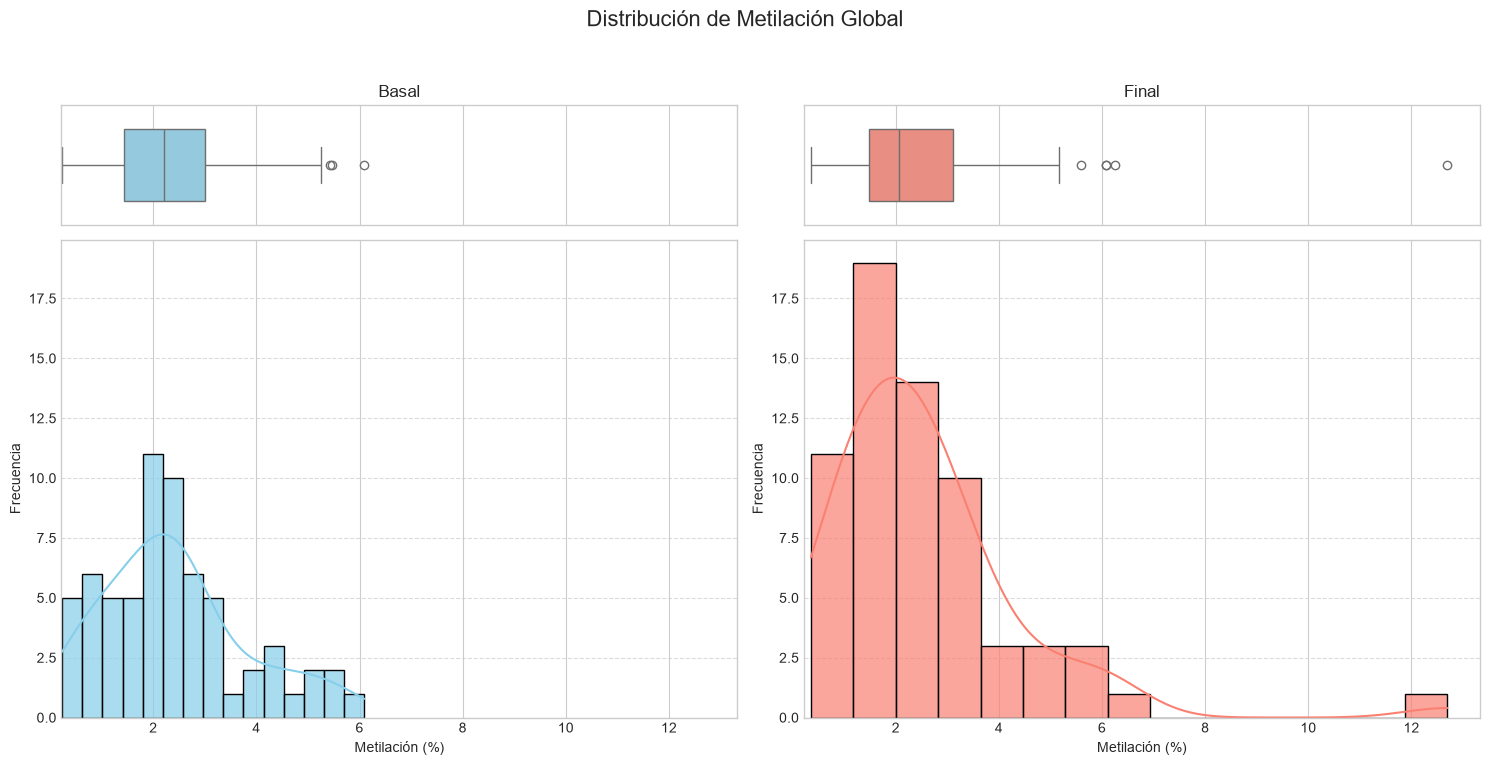

In [6]:
# ============================================================
# 5.1 Gráfico Combinado (Boxplot + Histograma) - Variable 1
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear una figura con dos filas y dos columnas, compartiendo el eje x por columna
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex='col', gridspec_kw={'height_ratios': [0.2, 0.8]})

# Calcular los datos del histograma para determinar el límite Y común
hist_bs, bins_bs = np.histogram(df['BS.EASIS'].dropna(), bins=15)
hist_fs, bins_fs = np.histogram(df['FS.EASIS'].dropna(), bins=15)
max_freq = max(hist_bs.max(), hist_fs.max())

# Calcular los límites del eje X comunes
min_x = min(df['BS.EASIS'].min(), df['FS.EASIS'].min())
max_x = max(df['BS.EASIS'].max(), df['FS.EASIS'].max())

fig.suptitle('Distribución de Estrés Académico SISCO-II', fontsize=16)

# Boxplot para el estrés académico basal (arriba izquierda)
sns.boxplot(x=df['BS.EASIS'].dropna(), ax=axes[0,0], color='skyblue', orient='h', width=0.6)
axes[0,0].set_title('Basal')
axes[0,0].set_xlabel('') # Eliminar etiqueta x para el boxplot
axes[0,0].set_yticks([]) # Eliminar ticks y del boxplot
axes[0,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para el estrés académico basal (abajo izquierda)
sns.histplot(df['BS.EASIS'].dropna(), bins=bins_bs, kde=True, color='skyblue', alpha=0.7, ax=axes[1,0])
axes[1,0].set_title('') # Eliminar título del histograma, ya cubierto por el boxplot o suptitle
axes[1,0].set_xlabel('Puntuación SISCO-II')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,0].set_ylim(0, max_freq * 1.05)
axes[1,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Boxplot para el estrés académico final (arriba derecha)
sns.boxplot(x=df['FS.EASIS'].dropna(), ax=axes[0,1], color='salmon', orient='h', width=0.6)
axes[0,1].set_title('Final')
axes[0,1].set_xlabel('') # Eliminar etiqueta x para el boxplot
axes[0,1].set_yticks([]) # Eliminar ticks y del boxplot
axes[0,1].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para el estrés académico final (abajo derecha)
sns.histplot(df['FS.EASIS'].dropna(), bins=bins_fs, kde=True, color='salmon', alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('') # Eliminar título del histograma, ya cubierto por el boxplot o suptitle
axes[1,1].set_xlabel('Puntuación SISCO-II')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,1].set_ylim(0, max_freq * 1.05)
axes[1,1].set_xlim(min_x * 0.95, max_x * 1.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar el diseño para evitar superposiciones, dejando espacio para suptitle
plt.show()

# ============================================================
# 5.2 Gráfico Combinado (Boxplot + Histograma) - Variable 2
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear una figura con dos filas y dos columnas, compartiendo el eje x por columna
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex='col', gridspec_kw={'height_ratios': [0.2, 0.8]})

# Calcular los datos del histograma para determinar el límite Y común
hist_bs, bins_bs = np.histogram(df['BS.RfsSIS'].dropna(), bins=15)
hist_fs, bins_fs = np.histogram(df['FS.RfsSIS'].dropna(), bins=15)
max_freq = max(hist_bs.max(), hist_fs.max())

# Calcular los límites del eje X comunes
min_x = min(df['BS.RfsSIS'].min(), df['FS.RfsSIS'].min())
max_x = max(df['BS.RfsSIS'].max(), df['FS.RfsSIS'].max())

fig.suptitle('Distribución de Reacciones Físicas/Psicológicas SISCO-II', fontsize=16)

# Boxplot para las reacciones físicas/psicológicas basales (arriba izquierda)
sns.boxplot(x=df['BS.RfsSIS'].dropna(), ax=axes[0,0], color='skyblue', orient='h', width=0.6)
axes[0,0].set_title('Basal')
axes[0,0].set_xlabel('')
axes[0,0].set_yticks([])
axes[0,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para las reacciones físicas/psicológicas basales (abajo izquierda)
sns.histplot(df['BS.RfsSIS'].dropna(), bins=bins_bs, kde=True, color='skyblue', alpha=0.7, ax=axes[1,0])
axes[1,0].set_title('')
axes[1,0].set_xlabel('Puntuación SISCO-II')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,0].set_ylim(0, max_freq * 1.05)
axes[1,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Boxplot para las reacciones físicas/psicológicas finales (arriba derecha)
sns.boxplot(x=df['FS.RfsSIS'].dropna(), ax=axes[0,1], color='salmon', orient='h', width=0.6)
axes[0,1].set_title('Final')
axes[0,1].set_xlabel('')
axes[0,1].set_yticks([])
axes[0,1].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para las reacciones físicas/psicológicas finales (abajo derecha)
sns.histplot(df['FS.RfsSIS'].dropna(), bins=bins_fs, kde=True, color='salmon', alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('')
axes[1,1].set_xlabel('Puntuación SISCO-II')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,1].set_ylim(0, max_freq * 1.05)
axes[1,1].set_xlim(min_x * 0.95, max_x * 1.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ============================================================
# 5.3 Gráfico Combinado (Boxplot + Histograma) - Variable 3
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear una figura con dos filas y dos columnas, compartiendo el eje x por columna
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex='col', gridspec_kw={'height_ratios': [0.2, 0.8]})

# Calcular los datos del histograma para determinar el límite Y común
hist_bs, bins_bs = np.histogram(df['BB.PT_prorrateado'].dropna(), bins=15)
hist_fs, bins_fs = np.histogram(df['FB.PT_prorrateado'].dropna(), bins=15)
max_freq = max(hist_bs.max(), hist_fs.max())

# Calcular los límites del eje X comunes
min_x = min(df['BB.PT_prorrateado'].min(), df['FB.PT_prorrateado'].min())
max_x = max(df['BB.PT_prorrateado'].max(), df['FB.PT_prorrateado'].max())

fig.suptitle('Distribución de BDI-II (Prorrateado)', fontsize=16)

# Boxplot para el BDI-II basal (arriba izquierda)
sns.boxplot(x=df['BB.PT_prorrateado'].dropna(), ax=axes[0,0], color='skyblue', orient='h', width=0.6)
axes[0,0].set_title('Basal')
axes[0,0].set_xlabel('')
axes[0,0].set_yticks([])
axes[0,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para el BDI-II basal (abajo izquierda)
sns.histplot(df['BB.PT_prorrateado'].dropna(), bins=bins_bs, kde=True, color='skyblue', alpha=0.7, ax=axes[1,0])
axes[1,0].set_title('')
axes[1,0].set_xlabel('Puntuación BDI-II')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,0].set_ylim(0, max_freq * 1.05)
axes[1,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Boxplot para el BDI-II final (arriba derecha)
sns.boxplot(x=df['FB.PT_prorrateado'].dropna(), ax=axes[0,1], color='salmon', orient='h', width=0.6)
axes[0,1].set_title('Final')
axes[0,1].set_xlabel('')
axes[0,1].set_yticks([])
axes[0,1].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para el BDI-II final (abajo derecha)
sns.histplot(df['FB.PT_prorrateado'].dropna(), bins=bins_fs, kde=True, color='salmon', alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('')
axes[1,1].set_xlabel('Puntuación BDI-II')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,1].set_ylim(0, max_freq * 1.05)
axes[1,1].set_xlim(min_x * 0.95, max_x * 1.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ============================================================
# 5.4 Gráfico Combinado (Boxplot + Histograma) - Variable 4
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear una figura con dos filas y dos columnas, compartiendo el eje x por columna
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex='col', gridspec_kw={'height_ratios': [0.2, 0.8]})

# Calcular los datos del histograma para determinar el límite Y común
hist_bs, bins_bs = np.histogram(df['BLAB.BDNF'].dropna(), bins=15)
hist_fs, bins_fs = np.histogram(df['FLAB.BDNF'].dropna(), bins=15)
max_freq = max(hist_bs.max(), hist_fs.max())

# Calcular los límites del eje X comunes
min_x = min(df['BLAB.BDNF'].min(), df['FLAB.BDNF'].min())
max_x = max(df['BLAB.BDNF'].max(), df['FLAB.BDNF'].max())

fig.suptitle('Distribución de BDNF', fontsize=16)

# Boxplot para BDNF basal (arriba izquierda)
sns.boxplot(x=df['BLAB.BDNF'].dropna(), ax=axes[0,0], color='skyblue', orient='h', width=0.6)
axes[0,0].set_title('Basal')
axes[0,0].set_xlabel('')
axes[0,0].set_yticks([])
axes[0,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para BDNF basal (abajo izquierda)
sns.histplot(df['BLAB.BDNF'].dropna(), bins=bins_bs, kde=True, color='skyblue', alpha=0.7, ax=axes[1,0])
axes[1,0].set_title('')
axes[1,0].set_xlabel('Concentración de BDNF (ng/ml)')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,0].set_ylim(0, max_freq * 1.05)
axes[1,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Boxplot para BDNF final (arriba derecha)
sns.boxplot(x=df['FLAB.BDNF'].dropna(), ax=axes[0,1], color='salmon', orient='h', width=0.6)
axes[0,1].set_title('Final')
axes[0,1].set_xlabel('')
axes[0,1].set_yticks([])
axes[0,1].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para BDNF final (abajo derecha)
sns.histplot(df['FLAB.BDNF'].dropna(), bins=bins_fs, kde=True, color='salmon', alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('')
axes[1,1].set_xlabel('Concentración de BDNF (ng/ml)')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,1].set_ylim(0, max_freq * 1.05)
axes[1,1].set_xlim(min_x * 0.95, max_x * 1.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ============================================================
# 5.5 Gráfico Combinado (Boxplot + Histograma) - Variable 5
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear una figura con dos filas y dos columnas, compartiendo el eje x por columna
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex='col', gridspec_kw={'height_ratios': [0.2, 0.8]})

# Calcular los datos del histograma para determinar el límite Y común
hist_bs, bins_bs = np.histogram(df['BLAB.Met'].dropna(), bins=15)
hist_fs, bins_fs = np.histogram(df['FLAB.Met'].dropna(), bins=15)
max_freq = max(hist_bs.max(), hist_fs.max())

# Calcular los límites del eje X comunes
min_x = min(df['BLAB.Met'].min(), df['FLAB.Met'].min())
max_x = max(df['BLAB.Met'].max(), df['FLAB.Met'].max())

fig.suptitle('Distribución de Metilación Global', fontsize=16)

# Boxplot para Metilación global basal (arriba izquierda)
sns.boxplot(x=df['BLAB.Met'].dropna(), ax=axes[0,0], color='skyblue', orient='h', width=0.6)
axes[0,0].set_title('Basal')
axes[0,0].set_xlabel('')
axes[0,0].set_yticks([])
axes[0,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para Metilación global basal (abajo izquierda)
sns.histplot(df['BLAB.Met'].dropna(), bins=bins_bs, kde=True, color='skyblue', alpha=0.7, ax=axes[1,0])
axes[1,0].set_title('')
axes[1,0].set_xlabel('Metilación (%)')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,0].set_ylim(0, max_freq * 1.05)
axes[1,0].set_xlim(min_x * 0.95, max_x * 1.05)

# Boxplot para Metilación global final (arriba derecha)
sns.boxplot(x=df['FLAB.Met'].dropna(), ax=axes[0,1], color='salmon', orient='h', width=0.6)
axes[0,1].set_title('Final')
axes[0,1].set_xlabel('')
axes[0,1].set_yticks([])
axes[0,1].set_xlim(min_x * 0.95, max_x * 1.05)

# Histograma para Metilación global final (abajo derecha)
sns.histplot(df['FLAB.Met'].dropna(), bins=bins_fs, kde=True, color='salmon', alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('')
axes[1,1].set_xlabel('Metilación (%)')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,1].set_ylim(0, max_freq * 1.05)
axes[1,1].set_xlim(min_x * 0.95, max_x * 1.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



### Lectura Descriptiva: Comparación Longitudinal Basal vs Final por Sexo (SISCO-II)

- **Desplazamiento longitudinal de las medianas:** En ambos sexos se observa un desplazamiento descriptivo hacia puntuaciones más altas al comparar la medición Basal con la Final:
  - **Mujeres:** La mediana se incrementa descriptivamente de **25.00** [IQR: 20.00–30.00] a **35.00** [IQR: 30.00–39.00] puntos (+10.00 pts).
  - **Hombres:** La mediana se incrementa descriptivamente de **22.50** [IQR: 18.25–26.00] a **30.00** [IQR: 22.75–35.25] puntos (+7.50 pts).
- **Relación descriptiva entre grupos:** En ambos momentos de evaluación (Basal y Final), las medianas muestrales del grupo femenino se ubican descriptivamente por encima de las del grupo masculino.
- **Evolución de la variabilidad (IQR):** En los hombres, el rango intercuartílico se ensancha en la medición final (IQR Basal = 7.75 vs Final = 12.50), sugiriendo mayor variabilidad individual en el término del período. En mujeres, el IQR se mantiene relativamente estable (IQR Basal = 10.00 vs Final = 9.00), manteniéndose el 75% del grupo en el tramo superior (Q1 = 30.00).


In [7]:
# ============================================================
# Incremento Neto (Delta: Final - Basal) en los 21 Ítems BDI-II
# ============================================================
import pandas as pd
import numpy as np
import plotly.graph_objects as go

bb_cols = [f'BB.{i}' for i in range(1, 22)]
fb_cols = [f'FB.{i}' for i in range(1, 22)]

df_items = df.copy()
for c in bb_cols + fb_cols:
    if c in df_items.columns:
        df_items[c] = df_items[c].replace(-9, np.nan)

item_labels = [
    '1. Tristeza', '2. Pesimismo', '3. Fracaso', '4. Pérdida de Placer',
    '5. Culpa', '6. Castigo', '7. Disconformidad', '8. Autocrítica',
    '9. Ideación Suicida (Riesgo)', '10. Llanto', '11. Agitación',
    '12. Pérdida de Interés', '13. Indecisión', '14. Inutilidad',
    '15. Pérdida de Energía', '16. Patrón de Sueño', '17. Irritabilidad',
    '18. Cambio de Apetito', '19. Concentración', '20. Cansancio/Fatiga',
    '21. Interés Sexual'
]

summary_items = []
for i in range(1, 22):
    b_c = f'BB.{i}'
    f_c = f'FB.{i}'
    b_m = df_items[b_c].mean() if b_c in df_items.columns else np.nan
    f_m = df_items[f_c].mean() if f_c in df_items.columns else np.nan
    diff = f_m - b_m
    summary_items.append({
        'Nombre': item_labels[i-1],
        'Basal': round(b_m, 2),
        'Final': round(f_m, 2),
        'Diff': round(diff, 2)
    })

df_res = pd.DataFrame(summary_items).sort_values(by='Diff', ascending=True)

fig_bdi21 = go.Figure()
fig_bdi21.add_trace(go.Bar(
    y=df_res['Nombre'],
    x=df_res['Diff'],
    orientation='h',
    marker=dict(
        color=df_res['Diff'],
        colorscale='Viridis',
        showscale=False
    ),
    hovertemplate='<b>%{y}</b><br>Incremento Medio (Δ): +%{x:.2f} pts<extra></extra>'
))

fig_bdi21.update_layout(
    title=dict(
        text='<b>Incremento Neto (Δ Final - Basal) en los 21 Ítems del BDI-II</b><br><sup>Diferencia de medias ordenadas de menor a mayor cambio sintomático</sup>',
        font=dict(size=15)
    ),
    xaxis_title='Diferencia Media (Puntos BDI-II: Final - Basal)',
    yaxis_title='Ítems del BDI-II',
    height=750,
    width=950,
    margin=dict(l=180, r=40, t=80, b=60),
    template='plotly_white'
)

fig_bdi21.write_image('fig4_bdi_21_items.png', scale=2)
fig_bdi21.show()


### Comparación por Sexo: Incremento Sintomático (Mujeres vs. Hombres)

Al desglosar el incremento neto ($\Delta = \text{Final} - \text{Basal}$) de las 21 preguntas entre **Mujeres ($N=41$)** y **Hombres ($N=24$)**, emergen patrones sintomáticos claramente diferenciados:

#### Diferencias Principales:
- **Respuesta Femenina (Mayor carga de cansancio somático y llanto):**
  - **Llanto (Ítem 10):** $+0.63$ en Mujeres vs. $+0.04$ en Hombres (diferencia de $+0.59$ pts).
  - **Cansancio / Fatiga (Ítem 20):** $+0.94$ en Mujeres vs. $+0.52$ en Hombres.
  - **Irritabilidad (Ítem 17):** $+0.78$ en Mujeres vs. $+0.44$ en Hombres.
- **Respuesta Masculina (Mayor carga cognitivo-evaluativa):**
  - **Disconformidad con uno mismo (Ítem 7):** $+0.54$ en Hombres vs. $+0.34$ en Mujeres.
  - **Pesimismo (Ítem 2):** $+0.50$ en Hombres vs. $+0.21$ en Mujeres.
  - **Pérdida de Placer (Ítem 4):** $+0.38$ en Hombres vs. $+0.14$ en Mujeres.

> **Conclusión EDA:** Mientras que las mujeres experimentan un mayor salto en síntomas de fatiga física, reactividad emocional (llanto) e irritabilidad, los hombres muestran un cambio orientado a la insatisfacción personal, pesimismo y anhedonia (pérdida de placer).

In [8]:
# ============================================================
# Incremento Neto en los 21 Ítems del BDI-II por Sexo (Plotly)
# ============================================================
import pandas as pd
import numpy as np
import plotly.graph_objects as go

bb_cols = [f'BB.{i}' for i in range(1, 22)]
fb_cols = [f'FB.{i}' for i in range(1, 22)]

df_items = df.copy()
for c in bb_cols + fb_cols:
    if c in df_items.columns:
        df_items[c] = df_items[c].replace(-9, np.nan)

item_labels = [
    '1. Tristeza', '2. Pesimismo', '3. Fracaso', '4. Pérdida de Placer',
    '5. Culpa', '6. Castigo', '7. Disconformidad', '8. Autocrítica',
    '9. Ideación Suicida (Riesgo)', '10. Llanto', '11. Agitación',
    '12. Pérdida de Interés', '13. Indecisión', '14. Inutilidad',
    '15. Pérdida de Energía', '16. Patrón de Sueño', '17. Irritabilidad',
    '18. Cambio de Apetito', '19. Concentración', '20. Cansancio/Fatiga',
    '21. Interés Sexual'
]

df_fem = df_items[df_items['.Sexo'] == 0]
df_mas = df_items[df_items['.Sexo'] == 1]

sex_items = []
for i in range(1, 22):
    b_c = f'BB.{i}'
    f_c = f'FB.{i}'
    diff_fem = df_fem[f_c].mean() - df_fem[b_c].mean()
    diff_mas = df_mas[f_c].mean() - df_mas[b_c].mean()
    sex_items.append({
        'Nombre': item_labels[i-1],
        'Delta_Mujeres': round(diff_fem, 2),
        'Delta_Hombres': round(diff_mas, 2)
    })

df_sex_res = pd.DataFrame(sex_items).sort_values(by='Delta_Mujeres', ascending=True)

fig_sex = go.Figure()
fig_sex.add_trace(go.Bar(
    y=df_sex_res['Nombre'],
    x=df_sex_res['Delta_Mujeres'],
    name='Mujeres',
    orientation='h',
    marker=dict(color='#e377c2'),
    hovertemplate='<b>%{y}</b><br>Mujeres Δ: +%{x:.2f} pts<extra></extra>'
))
fig_sex.add_trace(go.Bar(
    y=df_sex_res['Nombre'],
    x=df_sex_res['Delta_Hombres'],
    name='Hombres',
    orientation='h',
    marker=dict(color='#1f77b4'),
    hovertemplate='<b>%{y}</b><br>Hombres Δ: +%{x:.2f} pts<extra></extra>'
))

fig_sex.update_layout(
    title=dict(
        text='<b>Incremento Neto (Δ Final - Basal) en los 21 Ítems del BDI-II por Sexo</b><br><sup>Comparación de la respuesta sintomática entre Mujeres y Hombres</sup>',
        font=dict(size=15)
    ),
    barmode='group',
    xaxis_title='Incremento Medio (Puntos BDI-II: Final - Basal)',
    yaxis_title='Ítems del BDI-II',
    height=800,
    width=950,
    legend=dict(x=0.7, y=0.1, bgcolor='rgba(255,255,255,0.8)'),
    margin=dict(l=180, r=40, t=80, b=60),
    template='plotly_white'
)

fig_sex.write_image('fig5_bdi_21_items_sexo.png', scale=2)
fig_sex.show()


## Paso 6. Comparación descriptiva por sexo

Se utiliza `Sexo` según la codificación del CODEBOOK (`0 = F`, `1 = M`).

La comparación es **descriptiva**: mostrar medianas, IQR y distribuciones por sexo no equivale a concluir que exista una diferencia estadísticamente significativa.


In [9]:
# ============================================================
# 6. Resumen descriptivo de Reacciones Físicas y Psicológicas por sexo
# ============================================================
resumen_sexo = (
    df.groupby("Sexo_Label")
      .agg(
          N=("FS.RfsSIS", "count"),
          Basal_Mediana=("BS.RfsSIS", "median"),
          Basal_Q1=("BS.RfsSIS", lambda x: x.quantile(.25)),
          Basal_Q3=("BS.RfsSIS", lambda x: x.quantile(.75)),
          Final_Mediana=("FS.RfsSIS", "median"),
          Final_Q1=("FS.RfsSIS", lambda x: x.quantile(.25)),
          Final_Q3=("FS.RfsSIS", lambda x: x.quantile(.75))
      )
      .reset_index()
)

resumen_sexo["Basal_IQR"] = resumen_sexo["Basal_Q3"] - resumen_sexo["Basal_Q1"]
resumen_sexo["Final_IQR"] = resumen_sexo["Final_Q3"] - resumen_sexo["Final_Q1"]
resumen_sexo["Incremento_Mediana"] = resumen_sexo["Final_Mediana"] - resumen_sexo["Basal_Mediana"]

# Reordenar columnas para presentación clara
cols_orden = [
    "Sexo_Label", "N", 
    "Basal_Mediana", "Basal_Q1", "Basal_Q3", "Basal_IQR",
    "Final_Mediana", "Final_Q1", "Final_Q3", "Final_IQR",
    "Incremento_Mediana"
]

display(resumen_sexo[cols_orden].round(2))


,Sexo_Label,N,Basal_Mediana,Basal_Q1,Basal_Q3,Basal_IQR,Final_Mediana,Final_Q1,Final_Q3,Final_IQR,Incremento_Mediana
0,Hombre (M),24,22.5,18.25,26.0,7.75,30.0,22.75,35.25,12.5,7.5
1,Mujer (F),41,25.0,20.00,30.0,10.00,35.0,30.00,39.00,9.0,10.0


In [10]:
# Boxplot Agrupado (Basal vs Final) de Reacciones Físicas y Psicológicas (SISCO-II) por sexo con Plotly Express
df_rfs_long = df.melt(
    id_vars=['.ID', 'Sexo_Label'],
    value_vars=['BS.RfsSIS', 'FS.RfsSIS'],
    var_name='Momento_Col',
    value_name='Puntuacion'
).dropna(subset=['Puntuacion', 'Sexo_Label'])

df_rfs_long['Momento'] = df_rfs_long['Momento_Col'].map({
    'BS.RfsSIS': 'Basal',
    'FS.RfsSIS': 'Final'
})

fig_box = px.box(
    df_rfs_long,
    x='Sexo_Label',
    y='Puntuacion',
    color='Momento',
    category_orders={'Momento': ['Basal', 'Final'], 'Sexo_Label': ['Mujer (F)', 'Hombre (M)']},
    color_discrete_map={'Basal': '#3b82f6', 'Final': '#ef4444'},
    points=False,
    title='<b>Reacciones Físicas y Psicológicas (SISCO-II): Comparación Basal vs Final por Sexo</b>',
    labels={
        'Puntuacion': 'Puntuación Reacciones (SISCO-II)',
        'Sexo_Label': 'Sexo Biológico',
        'Momento': 'Momento de Medición'
    },
    template='plotly_white'
)

fig_box.update_layout(
    width=850,
    height=520,
    boxmode='group',
    legend=dict(
        title='Momento',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    )
)

fig_box.write_image('fig2_boxplot_sexo.png', scale=2)
fig_box.show()


### Lectura Descriptiva: Comparación Longitudinal Basal vs Final por Sexo (SISCO-II)

- **Desplazamiento longitudinal de las medianas:** En ambos sexos se observa un desplazamiento descriptivo hacia puntuaciones más altas al comparar la medición Basal con la Final:
  - **Mujeres:** La mediana se incrementa descriptivamente de **25.00** [IQR: 20.00–30.00] a **35.00** [IQR: 30.00–39.00] puntos (+10.00 pts).
  - **Hombres:** La mediana se incrementa descriptivamente de **22.50** [IQR: 18.25–26.00] a **30.00** [IQR: 22.75–35.25] puntos (+7.50 pts).
- **Relación descriptiva entre grupos:** En ambos momentos de evaluación (Basal y Final), las medianas muestrales del grupo femenino se ubican descriptivamente por encima de las del grupo masculino.
- **Evolución de la variabilidad (IQR):** En los hombres, el rango intercuartílico se ensancha en la medición final (IQR Basal = 7.75 vs Final = 12.50), sugiriendo mayor variabilidad individual en el término del período. En mujeres, el IQR se mantiene relativamente estable (IQR Basal = 10.00 vs Final = 9.00), manteniéndose el 75% del grupo en el tramo superior (Q1 = 30.00).


### Lectura descriptiva

En esta sección interesa principalmente observar:

- desplazamientos de la mediana entre basal y final;
- dispersión dentro de cada sexo;
- presencia de observaciones extremas;
- diferencias entre la media y la mediana del cambio porcentual de BDNF.

Una diferencia entre medias y medianas del cambio de BDNF puede ser una señal de influencia de observaciones extremas y debe considerarse antes de modelar.


## Paso 7. Correlaciones de Spearman

Se utiliza Spearman porque el objetivo es explorar asociaciones monotónicas y varias variables presentan asimetría.

La matriz se interpreta descriptivamente. Una correlación cercana a cero no demuestra ausencia absoluta de relación y una correlación distinta de cero no demuestra causalidad.


In [11]:
# ============================================================
# 7. Matriz de Correlación de Spearman y Tabla Resumen Interpretativa
# ============================================================
cols_corr = ['BS.EASIS', 'FS.EASIS', 'FS.RfsSIS', 'FB.PT_prorrateado', 'BLAB.BDNF', 'FLAB.BDNF', 'log_ratio_BDNF', 'FLAB.Met']
labels_corr = ['SISCO basal', 'SISCO final', 'Reacciones Físicas final', 'BDI final', 'BDNF basal', 'BDNF final', 'log(BDNF F/B)', 'Met final']
df_corr = df[cols_corr].corr(method='spearman').round(2)

fig_corr = px.imshow(
    df_corr.values, x=labels_corr, y=labels_corr,
    color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
    text_auto='.2f',
    title='<b>Matriz de Correlación de Spearman (Plotly - 2 Decimales)</b>',
    template='plotly_white'
)
fig_corr.update_layout(width=750, height=600)
fig_corr.show()

# Tabla resumen de interpretación descriptiva de pares principales
tabla_interpretacion_spearman = pd.DataFrame([
    {"Variable A": "SISCO final", "Variable B": "Reacciones Físicas final", "Spearman (ρ)": 0.90, "Fuerza y Dirección": "Muy Fuerte Positiva", "Interpretación Descriptiva": "El estrés académico global final y las reacciones somáticas/psicológicas varían casi a la par."},
    {"Variable A": "SISCO final", "Variable B": "BDI final", "Spearman (ρ)": 0.81, "Fuerza y Dirección": "Muy Fuerte Positiva", "Interpretación Descriptiva": "Estudiantes con mayor estrés final registran mayor intensidad en sintomatología depresiva."},
    {"Variable A": "Reacciones Físicas final", "Variable B": "BDI final", "Spearman (ρ)": 0.74, "Fuerza y Dirección": "Fuerte Positiva", "Interpretación Descriptiva": "Mayor reporte de manifestaciones somáticas de estrés se asocia con mayor puntuación depresiva."},
    {"Variable A": "BDNF basal", "Variable B": "BDNF final", "Spearman (ρ)": 0.48, "Fuerza y Dirección": "Moderada Positiva", "Interpretación Descriptiva": "Estabilidad moderada en los niveles plasmáticos de BDNF entre el inicio y final."},
    {"Variable A": "BDNF basal", "Variable B": "log(BDNF F/B)", "Spearman (ρ)": -0.44, "Fuerza y Dirección": "Moderada Negativa", "Interpretación Descriptiva": "Valores basales más altos de BDNF se asocian con incrementos relativos menores o leves reducciones."},
    {"Variable A": "SISCO basal", "Variable B": "BDI final", "Spearman (ρ)": 0.43, "Fuerza y Dirección": "Moderada Positiva", "Interpretación Descriptiva": "El estrés inicial muestra una co-variación moderada con la depresión evaluada al final."},
    {"Variable A": "SISCO basal", "Variable B": "SISCO final", "Spearman (ρ)": 0.40, "Fuerza y Dirección": "Moderada Positiva", "Interpretación Descriptiva": "Asociación positiva moderada entre la percepción de estrés al inicio y al final."},
    {"Variable A": "SISCO final", "Variable B": "Met final", "Spearman (ρ)": -0.22, "Fuerza y Dirección": "Débil Negativa", "Interpretación Descriptiva": "Leve tendencia inversa entre el estrés final y el porcentaje de metilación global final."},
    {"Variable A": "Reacciones Físicas final", "Variable B": "Met final", "Spearman (ρ)": -0.22, "Fuerza y Dirección": "Débil Negativa", "Interpretación Descriptiva": "Leve tendencia inversa entre reacciones físicas/psicológicas y metilación global final."},
    {"Variable A": "BDI final", "Variable B": "Met final", "Spearman (ρ)": -0.21, "Fuerza y Dirección": "Débil Negativa", "Interpretación Descriptiva": "Leve tendencia inversa entre síntomas depresivos finales y metilación global final."},
    {"Variable A": "SISCO final", "Variable B": "BDNF final", "Spearman (ρ)": 0.12, "Fuerza y Dirección": "Muy Débil Positiva", "Interpretación Descriptiva": "Co-variación directa casi nula entre el estrés final y la concentración final de BDNF."},
    {"Variable A": "BDI final", "Variable B": "BDNF final", "Spearman (ρ)": -0.01, "Fuerza y Dirección": "Nula", "Interpretación Descriptiva": "Ausencia de relación lineal/monotónica directa entre síntomas depresivos y BDNF final."}
])

display(tabla_interpretacion_spearman)


,Variable A,Variable B,Spearman (ρ),Fuerza y Dirección,Interpretación Descriptiva
0,SISCO final,Reacciones Físicas final,0.90,Muy Fuerte Positiva,El estrés académico global final y las reaccio...
1,SISCO final,BDI final,0.81,Muy Fuerte Positiva,Estudiantes con mayor estrés final registran m...
2,Reacciones Físicas final,BDI final,0.74,Fuerte Positiva,Mayor reporte de manifestaciones somáticas de ...
3,BDNF basal,BDNF final,0.48,Moderada Positiva,Estabilidad moderada en los niveles plasmático...
4,BDNF basal,log(BDNF F/B),-0.44,Moderada Negativa,Valores basales más altos de BDNF se asocian c...
5,SISCO basal,BDI final,0.43,Moderada Positiva,El estrés inicial muestra una co-variación mod...
6,SISCO basal,SISCO final,0.40,Moderada Positiva,Asociación positiva moderada entre la percepci...
7,SISCO final,Met final,-0.22,Débil Negativa,Leve tendencia inversa entre el estrés final y...
8,Reacciones Físicas final,Met final,-0.22,Débil Negativa,Leve tendencia inversa entre reacciones física...
9,BDI final,Met final,-0.21,Débil Negativa,Leve tendencia inversa entre síntomas depresiv...


## Paso 10. Hipótesis exploratorias e ideas para análisis posteriores

A partir del EDA pueden plantearse preguntas para análisis inferenciales posteriores, sin presentarlas como resultados confirmados.

### Pregunta 1 — Cambio en estrés académico

**¿Existe evidencia estadística de un cambio entre la evaluación basal y final del estrés académico SISCO-II?**

* **Hipótesis derivada del EDA ($H_1$):** Las puntuaciones de estrés académico (SISCO-II) registradas al término del período (evaluación final) exhiben un incremento descriptivo respecto a la evaluación basal, sugiriendo un aumento en la percepción del estrés en la cohorte estudiada.
* **Propuesta de análisis inferencial futuro:** Aplicar una prueba de rangos con signo de Wilcoxon para muestras pareadas (o modelo longitudinal de efectos mixtos).

---

### Pregunta 2 — Diferencias descriptivas según sexo

**¿Las distribuciones de reacciones físicas/psicológicas al final difieren según sexo?**

* **Hipótesis derivada del EDA ($H_1$):** Las estudiantes del grupo femenino presentan puntuaciones descriptivamente superiores en la subescala de reacciones físicas y psicológicas del estrés (SISCO-II final) en comparación con los estudiantes masculinos (Mediana = 35.00 vs 30.00 pts), sugiriendo diferencias en la carga sintomática por sexo.
* **Propuesta de análisis inferencial futuro:** Ejecutar una prueba U de Mann-Whitney para dos muestras independientes.

---

### Pregunta 3 — Biomarcadores y cambio longitudinal

**¿El cambio de BDNF o metilación presenta asociación con los indicadores de estrés/reacciones finales?**

* **Hipótesis derivada del EDA ($H_1$):** Las variaciones plasmáticas de BDNF y la metilación global del ADN no muestran una co-variación lineal/monotónica directa fuerte con la sintomatología percibida de estrés o depresión en la muestra observada.
* **Propuesta de análisis inferencial futuro:** Evaluar modelos de regresión multivariada controlando por variables de confusión biológicas y sociodemográficas.

---

## Alcances y Limitaciones del Análisis Exploratorio (EDA)

### Alcances
1. **Caracterización exhaustiva de variables:** Permitió examinar la forma de las distribuciones, detectar asimetrías y señalar valores atípicos (*outliers*) en variables psicométricas y biomarcadores.
2. **Fundamento metodológico riguroso:** Justificó técnicamente la selección de medidas robustas (Mediana e IQR) y correlaciones no paramétricas (Spearman).
3. **Generación de hipótesis guiadas por evidencia:** Identificó patrones longitudinales y diferencias descriptivas por sexo para orientar estudios inferenciales posteriores.

### Limitaciones
1. **Sin inferencia estadística confirmatoria:** Las diferencias observadas son puramente descriptivas y no cuentan con pruebas de hipótesis ni $p$-valores para determinar significancia estadística.
2. **Ausencia de causalidad:** Las asociaciones exploradas (matriz de Spearman) identifican co-variación muestral, pero no permiten establecer relaciones causales entre variables.
3. **Representatividad y tamaño muestral:** Muestra moderada ($N=65$; $n=41$ mujeres, $n=24$ hombres) con presencia de valores extremos en biomarcadores, lo que exige cautela y restringe la generalización de los resultados.


## Conclusiones del EDA

1. El conjunto contiene **65 participantes y 215 variables**, con múltiples instrumentos y mediciones basal/final.
2. El análisis prioriza variables resumen de SISCO-II, BDI-II, BDNF y metilación para reducir la dimensionalidad descriptiva sin perder los indicadores centrales del estudio.
3. Se identifican distribuciones asimétricas y observaciones extremas en algunas variables, particularmente en BDNF y metilación; por ello se reportan conjuntamente medidas robustas y clásicas.
4. Las comparaciones por sexo muestran diferencias descriptivas en las reacciones físicas/psicológicas y en la distribución del cambio de BDNF, pero estas diferencias no se interpretan como evidencia estadística sin un contraste formal.
5. La matriz de Spearman permite explorar asociaciones monotónicas entre los indicadores, evitando afirmar causalidad.
8. Los resultados constituyen una base para análisis inferenciales posteriores, pero **no permiten por sí solos establecer causalidad ni generalizar los hallazgos a otras poblaciones**.


## Limitaciones

- Tamaño muestral: `N = 65`.
- Diseño longitudinal con dos mediciones.
- Valores faltantes en algunas variables.
- Presencia de valores extremos, especialmente en biomarcadores.
- El prorrateo del BDI-II requiere una referencia metodológica explícita.|
- Las asociaciones descriptivas no establecen causalidad.
- La muestra corresponde al contexto específico descrito en el estudio; los resultados no deben generalizarse automáticamente a otras poblaciones.

### Para la siguiente etapa

Antes de realizar modelos inferenciales conviene:

1. documentar la fuente de las correcciones de fechas;
2. citar la regla de prorrateo del BDI-II;
3. decidir si los análisis usarán puntajes originales o prorrateados;
4. evaluar transformaciones de BDNF/metilación;
5. definir una estrategia para los datos faltantes;
6. considerar explícitamente la naturaleza longitudinal de los datos.
